# MCDI503 - Exploración Inteligente para la Ciencia de Datos
## Avance del Proyecto - Fase 1 (Evaluación Sumativa 1)

# I. Identificación del proyecto

**Título del avance:** Análisis exploratorio inicial y reproducible del dataset Titanic - Fase 1 del proyecto ABP.

**Integrantes del equipo:**

*   Pablo Balbontín
*   Melany Reyes
*   Ingeborg Muñoz
*   Mario López

**Docente responsable:** Raúl Calvo

**Fecha:** 13/09/2026

**Dataset utilizado:** Titanic (variables sociodemográficas y de viaje de los pasajeros del RMS Titanic, con la variable objetivo `survived`).

**Convención de nombres:** se conservan los nombres de columna nativos de la librería `seaborn`, en minúscula y sin renombrar. Esa misma convención se usa en todas las celdas narrativas de este notebook y en el informe complementario, de modo que cada variable mencionada en el texto corresponda literalmente a la columna del código.

**Propósito general del análisis:** Este notebook constituye la evidencia técnica principal del primer avance del proyecto ABP del curso. Su propósito es implementar, de forma reproducible, el primer ciclo de análisis exploratorio de datos (EDA) sobre el dataset Titanic: cargar y revisar la estructura del conjunto de datos, examinar su calidad, realizar una exploración preliminar de las variables relevantes, documentar las decisiones y transformaciones iniciales adoptadas, y sintetizar los primeros hallazgos. No se busca agotar el análisis ni construir modelos predictivos en esta fase, sino establecer una base técnica coherente, trazable y reproducible para las fases posteriores del proyecto.

# II. Contexto y objetivo exploratorio

**Contexto del problema:** El hundimiento del RMS Titanic (1912) es uno de los casos de estudio más utilizados en ciencia de datos para introducir el análisis exploratorio (Dogucu et al., 2025), dado que combina variables demográficas (sexo, edad), socioeconómicas (clase de pasaje, tarifa) y de composición familiar (número de acompañantes), junto con una variable binaria de resultado (supervivencia) y un patrón de valores faltantes no trivial. Comprender cómo se distribuyen estas variables y cómo se relacionan de manera preliminar con la supervivencia es un primer paso necesario antes de plantear cualquier modelamiento en fases posteriores del proyecto.

**Objetivo exploratorio del avance:** Explorar la estructura, calidad y patrones iniciales del dataset Titanic para identificar qué variables se asocian aparentemente con la supervivencia de los pasajeros, estableciendo una base técnica reproducible para las fases posteriores del proyecto.

**Preguntas exploratorias iniciales:**
1. ¿Cómo es la estructura del dataset y qué problemas de calidad presenta (valores nulos, duplicados, inconsistencias)?
2. ¿Cómo varía la tasa de supervivencia según el sexo y la edad de los pasajeros?
3. ¿Existe una relación aparente entre la clase de pasajero (`pclass`) y la supervivencia?
4. ¿Qué relación se observa entre la tarifa pagada (`fare`), la clase de pasajero y el puerto de embarque?
5. ¿Cómo varía la supervivencia según el tamaño del grupo familiar a bordo (`sibsp` + `parch`)?

**Alcance de este avance:** Esta fase cubre exclusivamente la carga, revisión inicial, exploración preliminar, transformaciones básicas (imputación y variables derivadas simples) y primeros hallazgos descriptivos. No se realiza modelamiento predictivo ni integración de tablas derivadas adicionales; estos componentes quedan explícitamente para fases posteriores del proyecto.

# III. Carga y revisión inicial de datos

Antes de explorar patrones, es necesario dejar constancia del entorno de trabajo (para asegurar reproducibilidad) y cargar el dataset, revisando su estructura, tipos de variables y estado general. Esta secuencia sigue el criterio de situar el problema y el dataset antes de mostrar resultados (Paraíso, 2026).

**Fuente de los datos:** no se encontró en la carpeta de trabajo del equipo un archivo previo con el dataset Titanic ya trabajado en actividades formativas; por lo tanto, como supuesto explícito de este avance, se utiliza la versión del dataset Titanic distribuida en la librería `seaborn` (Waskom, 2021), cargada con `sns.load_dataset("titanic")`. Se conservan sus nombres de columna nativos, en minúscula y sin renombrar ni estandarizar: `survived`, `pclass`, `sex`, `age`, `sibsp`, `parch`, `fare`, `embarked`, `deck` y `embark_town`.

**Dos particularidades de esta versión condicionan el análisis.** Primero, no incluye un identificador único de pasajero, lo que afecta la lectura del conteo de duplicados más adelante en esta misma sección. Segundo, la librería agrega cinco columnas derivadas que no forman parte del dataset original (`class`, `who`, `adult_male`, `alive`, `alone`); se examinan y descartan más abajo, antes de cualquier análisis. Ambos puntos se registran nuevamente en la sección VII.

In [ ]:
# Entorno de trabajo y librerías utilizadas
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Carpeta de salida para las figuras (ruta relativa a notebooks/, apunta a
# la carpeta figures/ en la raiz del proyecto, ya versionada con .gitkeep)
FIGURES_DIR = os.path.join("..", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

# Semilla fija para cualquier proceso con componente aleatorio (buena práctica de
# reproducibilidad). En esta fase el análisis es puramente descriptivo y no
# incorpora muestreo ni modelamiento estocástico, pero se fija igualmente por
# consistencia metodológica de cara a fases posteriores del proyecto.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print("Versiones de librerías utilizadas:")
print(f"  Python     : {sys.version.split()[0]}")
print(f"  pandas     : {pd.__version__}")
print(f"  numpy      : {np.__version__}")
print(f"  seaborn    : {sns.__version__}")
import matplotlib
print(f"  matplotlib : {matplotlib.__version__}")


Versiones de librerías utilizadas:
  Python     : 3.11.15
  pandas     : 3.0.2
  numpy      : 2.4.4
  seaborn    : 0.13.2
  matplotlib : 3.10.9


In [ ]:
# Carga del dataset
titanic = sns.load_dataset("titanic")
print("Dimensiones del dataset:", titanic.shape)
titanic.head(10)


Dimensiones del dataset: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [ ]:
# Estructura y tipos de variables
titanic.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


**Primeras observaciones sobre el estado general del dataset:** el conjunto contiene 891 registros (pasajeros) y 15 columnas, que corresponden a las diez variables originales del dataset Titanic más cinco columnas derivadas que agrega la propia librería. Entre las originales hay variables numéricas (`age`, `fare`, `sibsp`, `parch`), categóricas (`sex`, `embarked`, `embark_town`, `deck`) y variables binarias u ordinales codificadas numéricamente (`survived`, `pclass`). Se observan valores nulos en `age`, `embarked`, `embark_town` y `deck`, lo que se cuantifica más adelante en esta sección.

**Columnas derivadas que agrega la librería:** antes de revisar la calidad del dato se descartan las cinco columnas que `seaborn` construye a partir de las originales, por tres motivos. `alive` es la variable objetivo `survived` recodificada como texto ("yes"/"no"), de modo que conservarla implicaría arrastrar una copia literal de aquello que el análisis busca explicar. `class` y `alone` duplican información ya contenida en `pclass` y en la variable de composición familiar que se construye en la sección V. Y `who` junto con `adult_male` se derivan de `sex` y `age` aplicando cortes que el dataset no documenta. Se trabaja entonces solo con las diez variables originales, de manera que toda variable derivada utilizada más adelante se cree de forma explícita y trazable en este notebook.

In [ ]:
# Columnas derivadas que agrega seaborn y que se descartan del análisis
derivadas = ["class", "who", "adult_male", "alive", "alone"]
print("Muestra de las columnas derivadas antes de descartarlas:")
print(titanic[derivadas].head())

# Verificación de que 'alive' reproduce exactamente la variable objetivo
equivalencia = (titanic["alive"].map({"yes": 1, "no": 0}) == titanic["survived"]).all()
print("\n'alive' es equivalente a 'survived':", equivalencia)

titanic = titanic.drop(columns=derivadas)
print("\nColumnas conservadas:", titanic.shape[1])
print(list(titanic.columns))

Muestra de las columnas derivadas antes de descartarlas:
   class    who  adult_male alive  alone
0  Third    man        True    no  False
1  First  woman       False   yes  False
2  Third  woman       False   yes   True
3  First  woman       False   yes  False
4  Third    man        True    no   True

'alive' es equivalente a 'survived': True

Columnas conservadas: 10
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'deck', 'embark_town']


In [ ]:
# Revisión de valores faltantes y duplicados
faltantes = titanic.isna().sum().sort_values(ascending=False)
porcentaje_faltantes = (faltantes / len(titanic) * 100).round(1)
resumen_calidad = pd.DataFrame({"n_faltantes": faltantes, "pct_faltantes": porcentaje_faltantes})
print(resumen_calidad)

print("\nFilas completamente duplicadas:", titanic.duplicated().sum())


             n_faltantes  pct_faltantes
deck                 688           77.2
age                  177           19.9
embarked               2            0.2
embark_town            2            0.2
pclass                 0            0.0
survived               0            0.0
parch                  0            0.0
sibsp                  0            0.0
sex                    0            0.0
fare                   0            0.0

Filas completamente duplicadas: 107


**Lectura de la calidad mínima del dato:** `deck` presenta un 77,2% de valores faltantes, `age` un 19,9%, y `embarked` junto con `embark_town` solo 2 registros sin dato cada una. Respecto de los duplicados, `duplicated()` marca 107 filas: como esta versión del dataset no incorpora un identificador único de pasajero, dos personas distintas que compartan clase, sexo, edad, número de acompañantes, tarifa y puerto resultan indistinguibles para la función. Se interpretan, por tanto, como pasajeros distintos con atributos coincidentes y no como errores de carga, lectura que el dataset no permite verificar de forma directa al no incluir nombre ni número de ticket; el punto se registra como supuesto en la sección VII. Estas observaciones orientan las decisiones de la sección V.

# IV. Exploración preliminar

Con la estructura y calidad mínima ya revisadas, se avanza a una primera exploración descriptiva: estadísticos generales, distribución de variables relevantes y visualizaciones iniciales, sin todavía interpretar relaciones causales.


In [ ]:
# Estadísticas descriptivas de variables numéricas
titanic.describe()


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# Frecuencias de variables categóricas relevantes
for col in ["survived", "pclass", "sex", "embarked"]:
    print(f"\nFrecuencias de {col}:")
    print(titanic[col].value_counts(dropna=False))



Frecuencias de survived:
survived
0    549
1    342
Name: count, dtype: int64

Frecuencias de pclass:
pclass
3    491
1    216
2    184
Name: count, dtype: int64

Frecuencias de sex:
sex
male      577
female    314
Name: count, dtype: int64

Frecuencias de embarked:
embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64


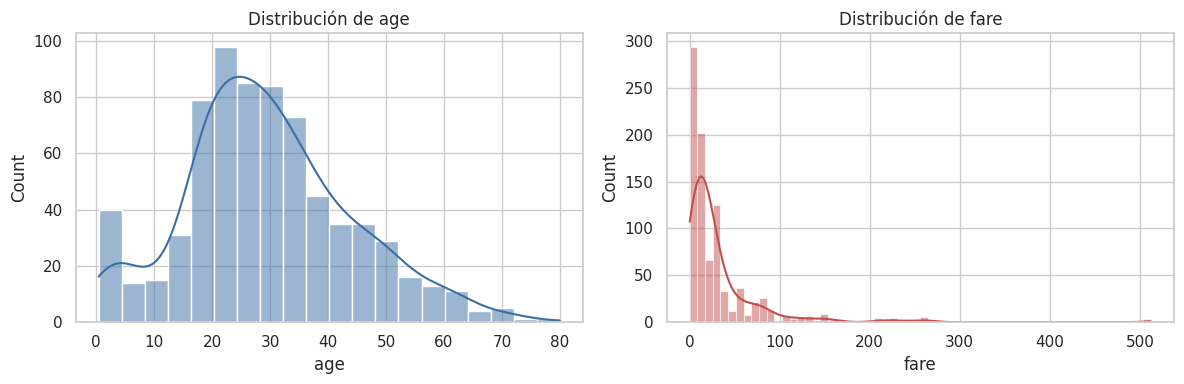

In [ ]:
# Distribuciones univariantes de variables numéricas clave
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(titanic["age"], kde=True, ax=axes[0], color="#3b6ea5")
axes[0].set_title("Distribución de age")
sns.histplot(titanic["fare"], kde=True, ax=axes[1], color="#c0504d")
axes[1].set_title("Distribución de fare")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig1.png"), dpi=300, bbox_inches="tight")
plt.show()

**Lectura orientativa:** `age` muestra una distribución aproximadamente unimodal, concentrada entre 20 y 40 años, con una cola derecha moderada. `fare` presenta una asimetría marcada hacia la derecha, es decir, la mayoría de los pasajeros pagó tarifas bajas y un grupo minoritario pagó tarifas muy altas, asociadas probablemente a primera clase; esto se contrasta en la sección VI.

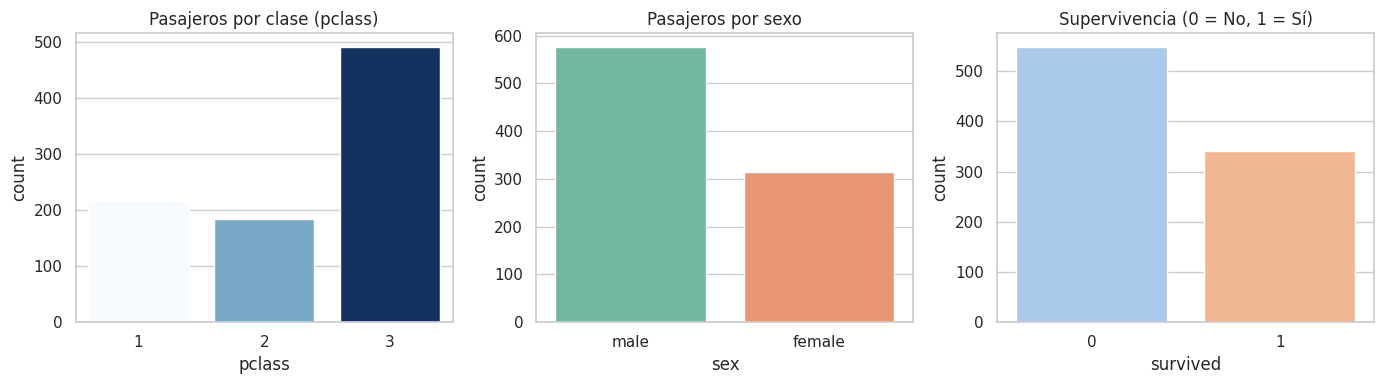

In [ ]:
# Distribución de variables categóricas relevantes
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.countplot(data=titanic, x="pclass", hue="pclass", palette="Blues", legend=False, ax=axes[0])
axes[0].set_title("Pasajeros por clase (pclass)")
sns.countplot(data=titanic, x="sex", hue="sex", palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("Pasajeros por sexo")
sns.countplot(data=titanic, x="survived", hue="survived", palette="pastel", legend=False, ax=axes[2])
axes[2].set_title("Supervivencia (0 = No, 1 = Sí)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig2.png"), dpi=300, bbox_inches="tight")
plt.show()

**Lectura orientativa:** la muestra está compuesta mayoritariamente por pasajeros de tercera clase y por hombres; la tasa de supervivencia global es minoritaria (más pasajeros no sobrevivieron que sobrevivieron). Estas proporciones son relevantes para interpretar con cautela las comparaciones de la sección VI, dado el desbalance de grupos.


# V. Decisiones y transformaciones iniciales

A partir de la revisión de calidad de la sección III, se adoptan las siguientes decisiones exploratorias. Cada una se documenta con su justificación y el resultado intermedio que produce, de modo que el proceso sea trazable.

**Decisión 1 - Imputación de `age`:** Se decide imputar los 177 valores faltantes de `age` (19,9%) usando la mediana de edad calculada por combinación de `pclass` y `sex`, en lugar de una mediana global, porque la edad mediana varía sensiblemente entre clases y sexos en este dataset, y una imputación más granular reduce el sesgo introducido. La imputación se aplica sobre la misma columna `age`, sin crear una copia adicional, y su efecto queda evidenciado mediante el conteo de nulos antes y después.

**Decisión 2 - Imputación de `embarked`:** Solo 2 registros no tienen puerto de embarque. Se decide imputar con la moda (valor más frecuente), dado que el efecto de 2 registros sobre el análisis agregado es marginal. Se aplica el mismo criterio a `embark_town`, que presenta esos mismos 2 registros sin dato.

**Decisión 3 - Tratamiento de `deck`:** Dado que `deck` tiene 77,2% de valores faltantes, no se imputa, porque una imputación con esa magnitud de faltantes introduciría más ruido que información. Se decide crear una variable binaria `deck_conocido` (1 si se registró la cubierta, 0 si no) para preservar la señal de dato disponible sin fabricar valores, y se deja pendiente para fases posteriores decidir si `deck` se descarta definitivamente o se recodifica.

**Decisión 4 - Variables derivadas de composición familiar:** Se crea `family_size = sibsp + parch + 1` (incluyendo al propio pasajero) e `is_alone` (1 si `family_size == 1`), para responder directamente la pregunta exploratoria 5. Ambas se construyen de forma explícita en lugar de reutilizar la columna `alone` que traía la librería y que se descartó en la sección III, de modo que la regla aplicada quede documentada en el propio notebook.

**Decisión 5 - Grupo etario:** Se crea la variable categórica `age_group` (Niño: 0–12, Joven: 13–25, Adulto: 26–59, Adulto mayor: 60+) a partir de `age` ya imputada, para simplificar la lectura de la relación edad–supervivencia en la sección VI.

In [ ]:
# Decisión 1: imputación de age por mediana de (pclass, sex)
print("Nulos en age antes de imputar:", titanic["age"].isna().sum())

mediana_age_grupo = titanic.groupby(["pclass", "sex"])["age"].median()
print("\nMediana de age por pclass y sex:")
print(mediana_age_grupo)

titanic["age"] = titanic.groupby(["pclass", "sex"])["age"].transform(
    lambda serie: serie.fillna(serie.median())
)
print("\nNulos en age después de imputar:", titanic["age"].isna().sum())

Nulos en age antes de imputar: 177

Mediana de age por pclass y sex:
pclass  sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: age, dtype: float64

Nulos en age después de imputar: 0


In [ ]:
# Decisión 2: imputación de embarked y embark_town por moda
print("Nulos en embarked antes de imputar:", titanic["embarked"].isna().sum())
moda_embarked = titanic["embarked"].mode()[0]
print("Moda utilizada:", moda_embarked)
titanic["embarked"] = titanic["embarked"].fillna(moda_embarked)
titanic["embark_town"] = titanic["embark_town"].fillna(titanic["embark_town"].mode()[0])
print("Nulos en embarked después de imputar:", titanic["embarked"].isna().sum())
print("Nulos en embark_town después de imputar:", titanic["embark_town"].isna().sum())

Nulos en embarked antes de imputar: 2
Moda utilizada: S
Nulos en embarked después de imputar: 0
Nulos en embark_town después de imputar: 0


In [ ]:
# Decisión 3: variable deck_conocido (sin imputar deck)
titanic["deck_conocido"] = titanic["deck"].notna().astype(int)
print(titanic["deck_conocido"].value_counts())

deck_conocido
0    688
1    203
Name: count, dtype: int64


In [ ]:
# Decisión 4: variables de composición familiar
titanic["family_size"] = titanic["sibsp"] + titanic["parch"] + 1
titanic["is_alone"] = (titanic["family_size"] == 1).astype(int)
titanic[["sibsp", "parch", "family_size", "is_alone"]].head()


,sibsp,parch,family_size,is_alone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


In [ ]:
# Decisión 5: grupo etario derivado de age ya imputada
bins_age = [0, 12, 25, 59, 100]
orden_age_group = ["Niño (0-12)", "Joven (13-25)", "Adulto (26-59)", "Adulto mayor (60+)"]
titanic["age_group"] = pd.cut(titanic["age"], bins=bins_age, labels=orden_age_group, right=True)
titanic["age_group"].value_counts().sort_index()

age_group
Niño (0-12)            69
Joven (13-25)         368
Adulto (26-59)        428
Adulto mayor (60+)     26
Name: count, dtype: int64

**Resultado intermedio de esta sección:** tras las transformaciones anteriores, el dataset de trabajo ya no presenta valores faltantes en `age`, `embarked` ni `embark_town`; `deck` se mantiene sin imputar pero acompañada de `deck_conocido` como señal explícita; y se cuenta con tres variables derivadas (`family_size`, `is_alone` y `age_group`) que permiten responder de forma más directa las preguntas exploratorias 2 y 5. Se verifica a continuación el estado final de nulos.

In [ ]:
# Verificación del estado de nulos tras las transformaciones
titanic.isna().sum().sort_values(ascending=False)


deck             688
survived           0
sex                0
age                0
sibsp              0
pclass             0
parch              0
fare               0
embarked           0
embark_town        0
deck_conocido      0
family_size        0
is_alone           0
age_group          0
dtype: int64

# VI. Resultados e interpretación inicial

Con el dataset transformado, se retoman explícitamente las cinco preguntas exploratorias planteadas en la sección II.

**Pregunta 1 (estructura y calidad del dataset):** quedó respondida en la sección III. El conjunto tiene 891 registros y diez variables originales; los faltantes se concentran en `deck` (77,2%) y `age` (19,9%), con 2 registros sin puerto de embarque; no se detectan inconsistencias de tipo o de rango en las variables numéricas; y las 107 filas que `duplicated()` marca se explican por la ausencia de un identificador único de pasajero en esta versión del dataset. Las preguntas 2 a 5 se abordan a continuación.

Tasa de supervivencia por sexo:
sex
female    0.742
male      0.189
Name: survived, dtype: float64

Tasa de supervivencia por grupo etario:
age_group
Niño (0-12)           0.580
Joven (13-25)         0.321
Adulto (26-59)        0.414
Adulto mayor (60+)    0.269
Name: survived, dtype: float64


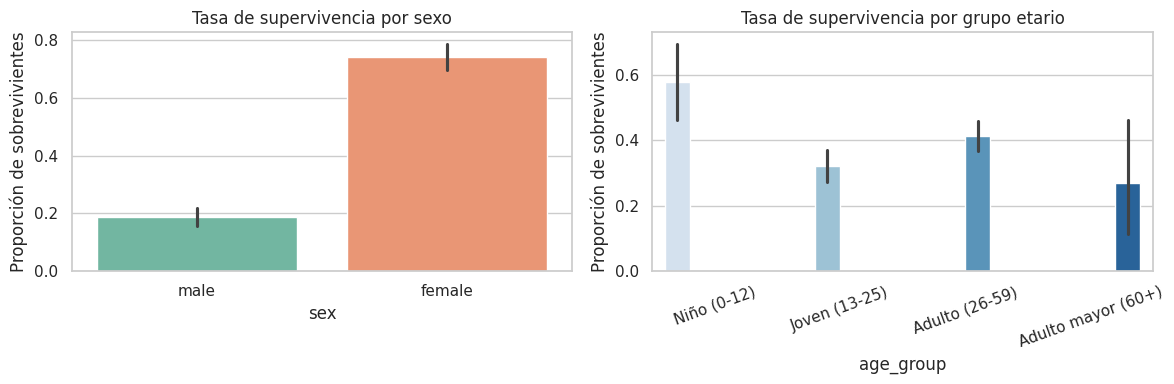

In [ ]:
# Pregunta 2: supervivencia según sexo y edad
tasa_por_sexo = titanic.groupby("sex")["survived"].mean().round(3)
print("Tasa de supervivencia por sexo:")
print(tasa_por_sexo)

tasa_por_edad = titanic.groupby("age_group", observed=True)["survived"].mean().round(3)
print("\nTasa de supervivencia por grupo etario:")
print(tasa_por_edad)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=titanic, x="sex", y="survived", hue="sex", palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("Tasa de supervivencia por sexo")
axes[0].set_ylabel("Proporción de sobrevivientes")

# orden_age_group se definió en la Decisión 5 y se reutiliza aquí para fijar
# el orden de las categorías en el eje x
sns.barplot(data=titanic, x="age_group", y="survived", hue="age_group", palette="Blues",
            legend=False, ax=axes[1], order=orden_age_group)
axes[1].set_title("Tasa de supervivencia por grupo etario")
axes[1].set_ylabel("Proporción de sobrevivientes")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig3.png"), dpi=300, bbox_inches="tight")
plt.show()

**Interpretación (Pregunta 2):** la tasa de supervivencia de las mujeres (74,2%) casi cuadruplica la de los hombres (18,9%), diferencia consistente con el patrón histórico de prioridad de evacuación. Por grupo etario, los niños de 0 a 12 años muestran la tasa más alta del conjunto (58,0%), claramente por encima del resto; le siguen los adultos de 26 a 59 años (41,4%), los jóvenes de 13 a 25 (32,1%) y los adultos mayores de 60 o más (26,9%). El orden no es monotónico respecto de la edad, de modo que el grupo etario por sí solo no ordena la supervivencia y conviene leerlo junto con el sexo y la clase en los apartados siguientes.

Tasa de supervivencia por clase:
pclass
1    0.630
2    0.473
3    0.242
Name: survived, dtype: float64


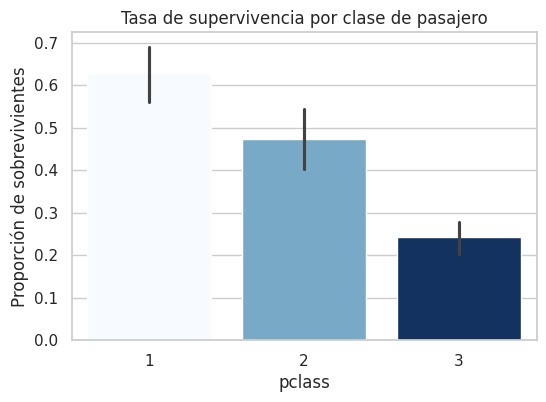

In [ ]:
# Pregunta 3: relación entre pclass y supervivencia
tasa_por_clase = titanic.groupby("pclass")["survived"].mean().round(3)
print("Tasa de supervivencia por clase:")
print(tasa_por_clase)

plt.figure(figsize=(6, 4))
sns.barplot(data=titanic, x="pclass", y="survived", hue="pclass", palette="Blues", legend=False)
plt.title("Tasa de supervivencia por clase de pasajero")
plt.ylabel("Proporción de sobrevivientes")
plt.savefig(os.path.join(FIGURES_DIR, "fig4.png"), dpi=300, bbox_inches="tight")
plt.show()

**Interpretación (Pregunta 3):** se observa una relación aparente clara entre clase de pasajero y supervivencia, que decrece de forma monotónica: 63,0% en primera clase, 47,3% en segunda y 24,2% en tercera. Esto es consistente con la hipótesis de que la clase se asocia con el acceso preferente a botes salvavidas y con la ubicación en el barco, aunque esta fase no establece causalidad.

Tarifa promedio por clase y puerto de embarque:
pclass  embarked
1       C           104.72
        Q            90.00
        S            70.51
2       C            25.36
        Q            12.35
        S            20.33
3       C            11.21
        Q            11.18
        S            14.64
Name: fare, dtype: float64


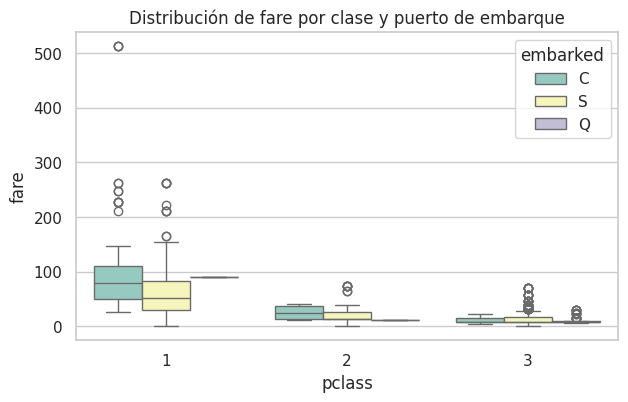

In [ ]:
# Pregunta 4: relación entre fare, pclass y puerto de embarque
resumen_fare = titanic.groupby(["pclass", "embarked"])["fare"].mean().round(2)
print("Tarifa promedio por clase y puerto de embarque:")
print(resumen_fare)

plt.figure(figsize=(7, 4))
sns.boxplot(data=titanic, x="pclass", y="fare", hue="embarked", palette="Set3")
plt.title("Distribución de fare por clase y puerto de embarque")
plt.savefig(os.path.join(FIGURES_DIR, "fig5.png"), dpi=300, bbox_inches="tight")
plt.show()

**Interpretación (Pregunta 4):** la tarifa promedio decrece de primera a tercera clase, como es esperable, y dentro de una misma clase existen diferencias según el puerto de embarque; Cherbourg concentra las tarifas más altas en primera clase (104,72 en promedio, frente a 70,51 en Southampton). Se observan además valores atípicos de `fare` en primera clase, coherentes con boletos de alto costo.

Tasa de supervivencia por tamaño de grupo familiar:
family_size
1     0.304
2     0.553
3     0.578
4     0.724
5     0.200
6     0.136
7     0.333
8     0.000
11    0.000
Name: survived, dtype: float64


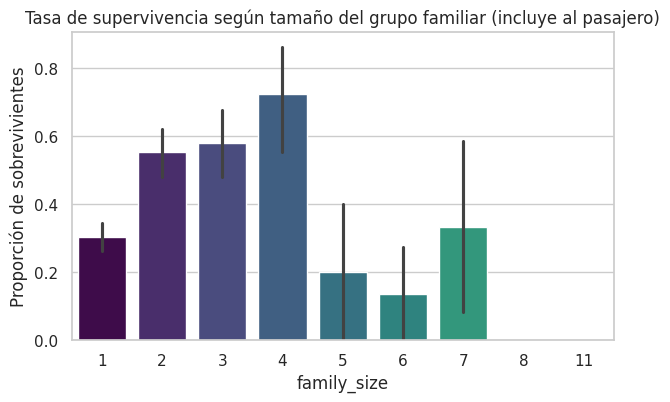

In [ ]:
# Pregunta 5: supervivencia según tamaño del grupo familiar
tasa_por_familia = titanic.groupby("family_size")["survived"].mean().round(3)
print("Tasa de supervivencia por tamaño de grupo familiar:")
print(tasa_por_familia)

plt.figure(figsize=(7, 4))
sns.barplot(data=titanic, x="family_size", y="survived", hue="family_size", palette="viridis", legend=False)
plt.title("Tasa de supervivencia según tamaño del grupo familiar (incluye al pasajero)")
plt.ylabel("Proporción de sobrevivientes")
plt.savefig(os.path.join(FIGURES_DIR, "fig6.png"), dpi=300, bbox_inches="tight")
plt.show()

**Interpretación (Pregunta 5):** los pasajeros que viajaban solos (`family_size` = 1) alcanzan un 30,4% de supervivencia y los grupos de cinco o más integrantes caen por debajo del 21%, mientras que los grupos de 2 a 4 integrantes presentan las tasas más altas (entre 55,3% y 72,4%). El patrón sugiere una relación no lineal entre tamaño de grupo y supervivencia, a explorar con mayor detalle en fases posteriores; conviene notar que los grupos de 7 o más reúnen muy pocos casos, por lo que sus tasas son poco estables.

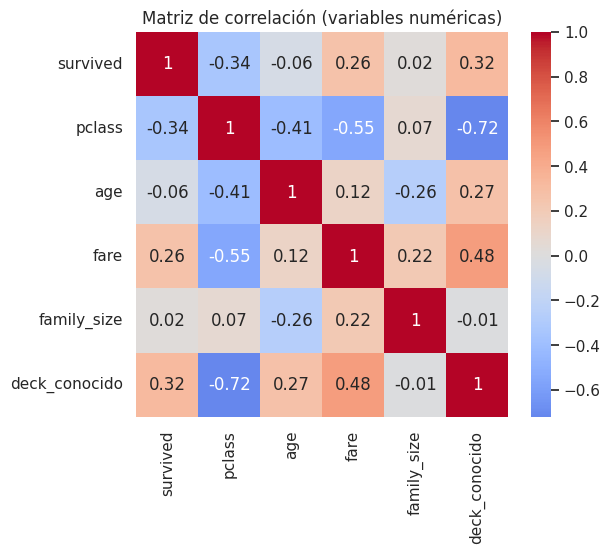

In [ ]:
# Correlación entre variables numéricas relevantes
variables_numericas = ["survived", "pclass", "age", "fare", "family_size", "deck_conocido"]
matriz_corr = titanic[variables_numericas].corr().round(2)

plt.figure(figsize=(6, 5))
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", center=0)
plt.title("Matriz de correlación (variables numéricas)")
plt.savefig(os.path.join(FIGURES_DIR, "fig7.png"), dpi=300, bbox_inches="tight")
plt.show()


**Interpretación general:** las asociaciones más fuertes con `survived` corresponden a `pclass`, de signo negativo (a mayor número de clase, es decir peor categoría, menor supervivencia), y a `deck_conocido`, de signo positivo. Esta última debe leerse con cuidado: mide la disponibilidad del registro de cubierta, no una característica del pasajero, y su asociación refleja probablemente que esa información se consignó de forma más completa para las clases altas. `fare` muestra una asociación positiva moderada, coherente con su relación con la clase. Estas relaciones son consistentes con lo observado en los gráficos anteriores y, en conjunto con la respuesta a la pregunta 1, cubren las cinco preguntas exploratorias planteadas en la sección II.

# VII. Supuestos y limitaciones

**Supuestos considerados durante el análisis:**
- Se asume que la versión del dataset Titanic distribuida por `seaborn` es equivalente, en su contenido sustantivo, a la versión clásica utilizada en actividades formativas previas del curso, dado que no se encontró un archivo previo del equipo en la carpeta de trabajo.
- Se asume que las 107 filas con atributos idénticos corresponden a pasajeros distintos con características coincidentes, y no a errores de carga o duplicación real de registros. Esta versión del dataset no incluye un identificador único de pasajero, ni nombre ni número de ticket, por lo que la afirmación no puede verificarse de forma directa.
- Se asume que las cinco columnas derivadas descartadas en la sección III (`class`, `who`, `adult_male`, `alive` y `alone`) no aportan información adicional a la contenida en las diez variables originales.
- Se asume que la imputación de `age` por mediana de (`pclass`, `sex`) es una aproximación razonable para esta fase exploratoria, sin pretender ser la estrategia definitiva de tratamiento de nulos del proyecto.

**Limitaciones detectadas:**
- `deck` mantiene un 77,2% de valores faltantes no imputados; cualquier análisis que la involucre debe considerarse preliminar y de baja confiabilidad.
- La imputación de `age` por mediana de grupo reduce la varianza de la variable y atenúa su correlación lineal con `survived`; el valor cercano a cero que muestra la matriz de correlación no debe interpretarse, por lo tanto, como ausencia de relación entre edad y supervivencia.
- `deck_conocido` es una variable de disponibilidad del dato y no un atributo del pasajero, de modo que su asociación con la supervivencia no admite lectura causal.
- El análisis presentado es descriptivo y bivariado; no se han evaluado interacciones múltiples entre variables ni la significancia estadística de las diferencias observadas.
- La muestra está desbalanceada en `sex` y `pclass`, y algunos tamaños de grupo familiar reúnen muy pocos casos, lo que puede amplificar visualmente ciertas diferencias de tasas.

**Aspectos pendientes para fases siguientes:**
- Definir el tratamiento final de `deck` (descarte, recodificación agregada u otra estrategia).
- Evaluar pruebas de significancia estadística sobre las diferencias de supervivencia identificadas.
- Avanzar hacia la integración de tablas derivadas y, eventualmente, el modelamiento predictivo, conforme lo indiquen las fases posteriores del proyecto.

# VIII. Cierre del avance

En este primer avance se cargó y revisó el dataset Titanic, se descartaron las cinco columnas derivadas que agrega la librería, se evaluó la calidad del dato (identificando nulos en `age`, `embarked`, `embark_town` y `deck`, y 107 filas con atributos coincidentes), se realizó una exploración preliminar de las variables principales y se documentaron cinco decisiones de transformación: imputación de `age` y de `embarked`, tratamiento de `deck` mediante `deck_conocido`, y creación de las variables derivadas `family_size`, `is_alone` y `age_group`.

**Principales hallazgos de esta fase:** la supervivencia se asocia de forma aparente con el sexo (74,2% en mujeres frente a 18,9% en hombres), con la clase de pasajero (63,0%, 47,3% y 24,2% de primera a tercera), con el grupo etario (mayor en niños de 0 a 12 años) y con el tamaño del grupo familiar (más alta en grupos de 2 a 4 integrantes que entre quienes viajaban solos o en grupos muy numerosos). La tarifa se relaciona con la clase y, en menor medida, con el puerto de embarque.

**Proyección para las siguientes fases:** se espera profundizar el análisis bivariado con pruebas estadísticas formales, resolver el tratamiento definitivo de `deck`, y avanzar hacia la integración de tablas derivadas y el modelamiento predictivo de la supervivencia, construyendo sobre la base reproducible establecida en este avance.